In [1]:
from itertools import product
from typing import Any, Dict, Iterable
from datetime import datetime

from sklearn.metrics import mean_squared_error
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN
import pandas as pd
import numpy as np
import os
import re
import tensorflow as tf
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os


2025-04-08 15:26:55.558173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744118815.588713    9986 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744118815.597835    9986 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-08 15:26:55.620442: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
alpha : -1.0
beta : 1.0
delta : 1.0
x0 : 0.01
x_t0 : 0.0
T : 12.5
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5


In [3]:
config["activation"] = "swish"
config["N_hidden"] = 4
config["N_neurons"] = 50
config["N_epochs"] = 25000
config["T"] = 12.5
config["x0"] = 0.1
config["x_t0"] = 0.0
config["freq_save"] = 0
config["regularization"] = "no_reg"
PINN_unmodified = PhysicsInformedNN(config, verbose=True)
training_log = PINN_unmodified.train()

/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1744118818.307476    9986 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1733 MB memory:  -> device: 0, name: NVIDIA GeForce MX250, pci bus id: 0000:3c:00.0, compute capability: 6.1


Model: "PhysicsInformedNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801 (30.47 KB)

 Trainable params: 7,801 (30.47 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***
Training started...
    0/25000 | loss_P: 2.43e-04 | loss_IC: 1.00e-02
 1000/25000 | loss_P: 1.18e-03 | loss_IC: 5.14e-04
 2000/25000 | loss_P: 1.41e-03 | loss_IC: 5.10e-04
 3000/25000 | loss_P: 1.43e-03 | loss_IC: 4.96e-04
 4000/25000 | loss_P: 1.46e-03 | loss_IC: 4.22e-04
 5000/25000 | loss_P: 1.48e-03 | loss_IC: 4.27e-04
 6000/25000 | loss_P: 1.45e-03 | loss_IC: 4.48e-04
 7000/25000 | loss_P: 1.37e-03 | loss_IC: 5.38e-04
 8000/25000 | loss_P: 1.53e-03 | loss_IC: 4.54e-04
 9000/25000 | loss_P: 1.47e-03 | loss_IC: 4.60e-04
10000/25000 | loss_P: 1.16e-03 | loss_IC: 5.29e-04
11000/25000 | loss_P: 1.39e-03 | loss_IC: 5.40e-04
12000/25000 | loss_P: 1.53e-03 | loss_IC: 5.09e-04
13000/25000 | loss_P: 1.32e-03 | loss_IC: 5.18e-04
14000/25000 | loss_P: 1.37e-03 | loss_IC: 4.62e-04
15000/25000 | loss_P: 1.34e-03 | loss_IC: 5.23e-04
16000/25000 | loss_P: 1.45e-03 | loss_IC: 4.74e-04
17000/25000 | loss_P: 1.29e-03 | loss_IC: 5.25e-04
18000/25000 | loss_P: 1.56e-0

In [4]:
config["activation"] = "swish"
config["N_hidden"] = 4
config["N_neurons"] = 50
config["N_epochs"] = 25000
config["T"] = 12.5
config["freq_save"] = 0
config["regularization"] = "reg_derivative_unstable_fp"
config["reg_coeff"] = 1.0
config["reg_epochs"] = 0.5
config["reg_decay"] = "linear"
PINN_reg_unstable_fp = PhysicsInformedNN(config, verbose=True)
training_log = PINN_reg_unstable_fp.train()

Model: "PhysicsInformedNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801 (30.47 KB)

 Trainable params: 7,801 (30.47 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***
Training started...
    0/25000 | loss_P: 5.92e-01 | loss_IC: 1.00e-02
 1000/25000 | loss_P: 2.08e-03 | loss_IC: 1.88e-04
 2000/25000 | loss_P: 2.27e-03 | loss_IC: 1.60e-04
 3000/25000 | loss_P: 2.24e-03 | loss_IC: 1.19e-04
 4000/25000 | loss_P: 2.07e-03 | loss_IC: 1.04e-04
 5000/25000 | loss_P: 2.00e-03 | loss_IC: 2.28e-04
 6000/25000 | loss_P: 1.85e-03 | loss_IC: 9.97e-05
 7000/25000 | loss_P: 1.76e-03 | loss_IC: 1.28e-04
 8000/25000 | loss_P: 1.67e-03 | loss_IC: 1.24e-04
 9000/25000 | loss_P: 1.60e-03 | loss_IC: 5.57e-05
10000/25000 | loss_P: 1.21e-03 | loss_IC: 6.46e-05
11000/25000 | loss_P: 1.16e-03 | loss_IC: 5.98e-05
12000/25000 | loss_P: 7.28e-04 | loss_IC: 3.59e-05
13000/25000 | loss_P: 9.42e-05 | loss_IC: 3.89e-07
14000/25000 | loss_P: 1.18e-05 | loss_IC: 1.81e-07
15000/25000 | loss_P: 2.53e-05 | loss_IC: 1.64e-07
16000/25000 | loss_P: 5.87e-06 | loss_IC: 4.98e-07
17000/25000 | loss_P: 1.37e-06 | loss_IC: 2.51e-09
18000/25000 | loss_P: 2.58e-0

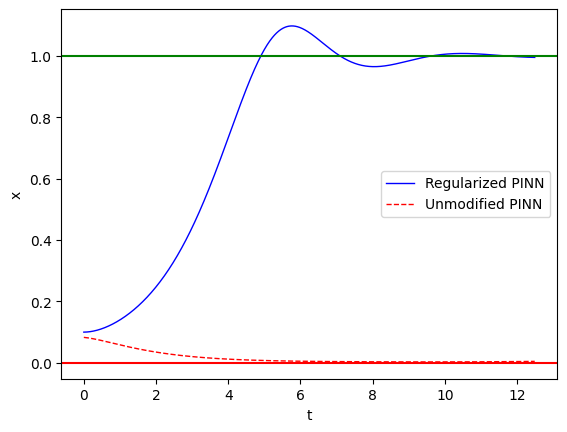

Text(0, 0.5, 'x_t')

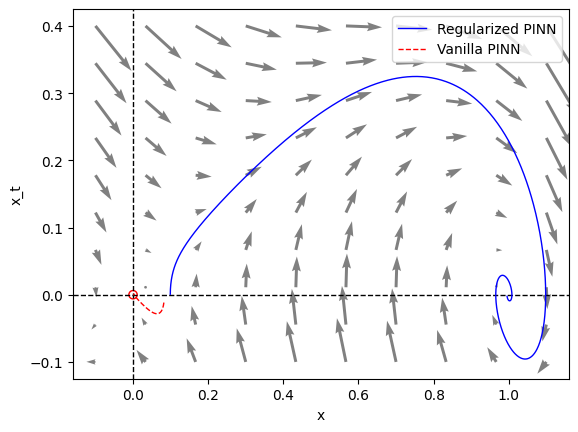

In [ ]:
t_line, x_true, x_t_true = PINN_unmodified.data.reference()
x_pred_unmodified = PINN_unmodified(t_line)
x_t_pred_unmodified = PINN_unmodified.x_t(t_line)

x_pred_reg_unstable_fp = PINN_reg_unstable_fp(t_line)
x_t_pred_reg_unstable_fp = PINN_reg_unstable_fp.x_t(t_line)

# 1D Plot
plt.figure()
plt.plot(t_line, x_pred_reg_unstable_fp, c='blue', lw=1, label='Regularized PINN')
plt.plot(t_line, x_pred_unmodified, c='red', lw=1, ls='--', label='Unmodified PINN')
plt.axhline(0, c='r')
plt.axhline(1, c='g')
plt.xlabel(f"t")
plt.ylabel(f"x")
plt.legend()
plt.show()

# 2D Plot
plt.figure()
xscale, yscale, n_arrows = 1.2, 2, 10
x = np.linspace(-0.1, 1.1, n_arrows)
x_t = np.linspace(-0.1, 1.1, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dx_t] = PINN_unmodified.data.diff_equations(t, Y)
x, x_t = XX.flatten(), YY.flatten()
plt.quiver(x, x_t, dx, dx_t, color='0.5')
# Fixed Points
plt.scatter(0, 0, edgecolors='r', facecolors='none')
# Axis lines
plt.axhline(0, lw=1, ls='--', c='black')
plt.axvline(0, lw=1, ls='--', c='black')

# Plot trajectories
plt.plot(x_pred_reg_unstable_fp, x_t_pred_reg_unstable_fp, c='blue', lw=1, label='Regularized PINN')
plt.plot(x_pred_unmodified, x_t_pred_unmodified, c='red', lw=1, ls='--', label='Vanilla PINN')
plt.legend()
plt.xlabel(f"x")
plt.ylabel(f"x_t")
